
ERICK BADILLO RANGEL <br>
MATRICULA: 741550 <br>
APRENDIZAJE AUTOMÁTICO <br>
<br>
TAREA 1

Contexto
El conjunto de datos de CalCOFI representa la serie temporal más larga (desde 1949 hasta el presente) y más completa (más de 50 000 estaciones de muestreo) de datos oceanográficos y de larvas de peces del mundo. Incluye datos de abundancia de larvas de más de 250 especies de peces; datos de frecuencia de longitud de larvas y datos de abundancia de huevos en especies comerciales clave; y datos oceanográficos y de plancton. Los datos físicos, químicos y biológicos recopilados a intervalos regulares de tiempo y espacio rápidamente se volvieron valiosos para documentar los ciclos climáticos en la Corriente de California y una variedad de respuestas biológicas a ellos. La investigación de CalCOFI llamó la atención mundial sobre la respuesta biológica al dramático evento de calentamiento del Pacífico en 1957-58 e introdujo el término "El Niño" en la literatura científica.

Las Investigaciones Cooperativas de Pesca Oceánica de California (CalCOFI) son una asociación única del Departamento de Pesca y Vida Silvestre de California, el Servicio de Pesca de la NOAA y la Institución Scripps de Oceanografía. La organización se formó en 1949 para estudiar los aspectos ecológicos del colapso de la población de sardinas frente a California. Hoy nuestro enfoque se ha desplazado al estudio del medio ambiente marino frente a las costas de California, la gestión de sus recursos vivos y el seguimiento de los indicadores de El Niño y el cambio climático. CalCOFI realiza cruceros trimestrales frente al sur y centro de California, recopilando un conjunto de datos hidrográficos y biológicos en la estación y en marcha. Los datos recopilados a profundidades de hasta 500 m incluyen: temperatura, salinidad, oxígeno, fosfato, silicato, nitrato y nitrito, clorofila, transmisómetro, PAR, productividad primaria C14, biodiversidad de fitoplancton, biomasa de zooplancton y biodiversidad de zooplancton.

Dataset: https://www.kaggle.com/datasets/sohier/calcofi

In [19]:
import numpy as np
import pandas as pd

data = pd.read_csv('data/bottle.csv')


C:\Users\erick\AppData\Local\Temp\ipykernel_19620\3152140224.py:4: DtypeWarning: Columns (47,73) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('data/bottle.csv')


In [20]:
data = pd.DataFrame(data)
data.head()

,Cst_Cnt,Btl_Cnt,Sta_ID,Depth_ID,Depthm,T_degC,Salnty,O2ml_L,STheta,O2Sat,...,R_PHAEO,R_PRES,R_SAMP,DIC1,DIC2,TA1,TA2,pH2,pH1,DIC Quality Comment
0,1,1,054.0 056.0,19-4903CR-HY-060-0930-05400560-0000A-3,0,10.50,33.440,NaN,25.649,NaN,...,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2,054.0 056.0,19-4903CR-HY-060-0930-05400560-0008A-3,8,10.46,33.440,NaN,25.656,NaN,...,NaN,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,3,054.0 056.0,19-4903CR-HY-060-0930-05400560-0010A-7,10,10.46,33.437,NaN,25.654,NaN,...,NaN,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,4,054.0 056.0,19-4903CR-HY-060-0930-05400560-0019A-3,19,10.45,33.420,NaN,25.643,NaN,...,NaN,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,5,054.0 056.0,19-4903CR-HY-060-0930-05400560-0020A-7,20,10.45,33.421,NaN,25.643,NaN,...,NaN,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
salt_degree=data[['Salnty', 'T_degC']].dropna()

print(salt_degree.dtypes)
salt_degree.head()

Salnty    float64
T_degC    float64
dtype: object


,Salnty,T_degC
0,33.440,10.50
1,33.440,10.46
2,33.437,10.46
3,33.420,10.45
4,33.421,10.45


In [22]:
n = 100000
x = salt_degree['Salnty'].head(n).to_numpy()
y = salt_degree['T_degC'].head(n).to_numpy()

print(f'n={n}')
print(f'x={x}')
print(f'y={y}')

n=100000
x=[33.44  33.44  33.437 ... 34.09  34.091 34.14 ]
y=[10.5  10.46 10.46 ...  5.66  5.65  5.1 ]


In [23]:
n = len(x)
r = 0
_x = sum(x)
_y = sum(y)

_x_2 = 0
for i in range(len(x)):
  r += x[i]*y[i]
  _x_2 += x[i]**2

print(f'n={n}')
print(f'r={r}')
print(f'_x={_x}')
print(f'_y={_y}')
print(f'_x_2={_x_2}')

n=100000
r=32089673.023140363
_x=3388712.1570000513
_y=951138.5399999905
_x_2=114860205.5309271


In [24]:
m = (n * r - _x * _y) / (n * _x_2 - _x**2)
b = (_y - m *_x) / n

print(f'm = {m}')
print(f'b = {b}')

m = -5.345252230485492
b = 190.6465975567782


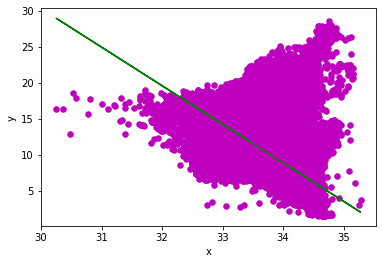

In [25]:
import matplotlib.pyplot as plt

plt.scatter(x, y, color = "m", marker = "o", s = 30) 
 
y_pred = b + m*x 

plt.plot(x, y_pred, color = "g") 

plt.xlabel('x') 
plt.ylabel('y') 
plt.show() 